In [1]:
import numpy as np
import yaml
import os
from classy import Class
import matplotlib.pyplot as plt
from pybird_master.greenfunction import GreenFunction
from scipy.integrate import quad


In [2]:
def get_cosmo_at_z(z,w0,wa=0):
    M = Class()
    cosmo1 = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}
    if w0 is not None:
        cosmo1.update({'Omega_Lambda':0,
              'w0_fld':w0,
            'wa_fld':wa})
    M.set(cosmo1)
    M.set({'output': 'mPk', 'P_k_max_h/Mpc': 10, 'z_max_pk': z})
    M.compute()
    kk = np.logspace(-5, 0, 200)
    pk_lin = np.array([M.pk_lin(k*M.h(), z)*M.h()**3 for k in kk]) 
    D1, f1 = M.scale_independent_growth_factor(z), M.scale_independent_growth_factor_f(z)
    return M,kk,pk_lin,D1,f1


def get_D(z,M):
    kk = [0.1]   # h/Mpc
    #kk = [0.1/M.h()]   # k[1/Mpc]=0.1-->k[h/Mpc]=0.1/h
    pk_lin = np.array([M.pk_lin(k*M.h(), z)*M.h()**3 for k in kk])
    pk0_lin = np.array([M.pk_lin(k*M.h(), 0)*M.h()**3 for k in kk])
    return M.scale_independent_growth_factor(z)  # #np.sqrt(pk_lin/pk0_lin)[0] #

# power spectrum ratio

In [3]:
from pybird_master.greenfunction import GreenFunction


In [4]:
def get_cq_pkratio(z,w0,wa=0,zm=5,cq=True):
    M,_,_,_,_ = get_cosmo_at_z(zm,w0,wa)
    zfid = z
    def scale_factor(z): return 1/(1.+z)
    Omega0_m = M.Omega0_m()

    GF = GreenFunction(Omega0_m, w=w0,wa=wa, quintessence=cq)
    Dq = GF.D(scale_factor(zfid)) / GF.D(scale_factor(zm))
    #Dm = M.scale_independent_growth_factor(zfid) / M.scale_independent_growth_factor(zm)
    Dm = get_D(zfid,M)/get_D(zm,M)
    def C(a):
        if wa==0 or wa==None:
            return 1+(1+w0)*(1-Omega0_m)/Omega0_m*a**(-3*w0)
        elif wa!=0:
            return 1+(1+w0+wa-a*wa)*(1-Omega0_m)/Omega0_m*a**(-3*w0-3*wa)*np.exp(3*wa*(a-1))
        else:
            raise ValueError('error about dark energy settings')
    am = 1/(1+zm)
    if cq:
        factor = quad(C,0,am)[0]/am
    else:
        factor = 1
    return Dq**2 / Dm**2 *factor**2#

In [13]:
z=0.32
zm = np.linspace(5,11,20)
sq_r = np.zeros_like(zm)
cq_r = np.zeros_like(zm)

w0 = -0.9
wa = 0.
for i in range(len(zm)):
    sq_r[i] = get_cq_pkratio(z=z,w0=w0,wa=wa,zm=zm[i],cq=False)
    cq_r[i] = get_cq_pkratio(z=z,w0=w0,wa=wa,zm=zm[i],cq=True)

(0.001, 0.01)

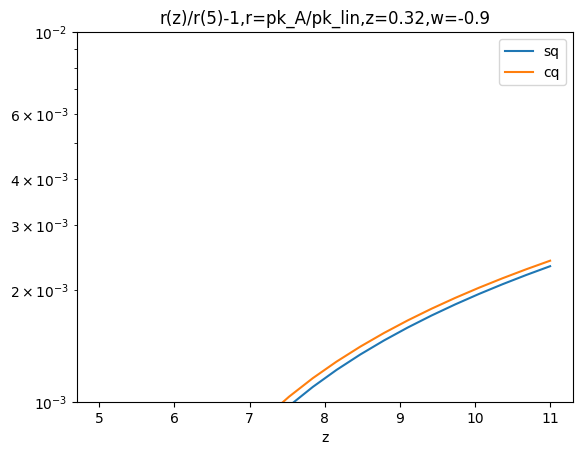

In [15]:
plt.plot(zm,abs(sq_r/sq_r[0]-1),label='sq')
plt.plot(zm,abs(cq_r/cq_r[0]-1),label='cq')
plt.semilogy()
plt.legend()
plt.title('r(z)/r(5)-1,r=pk_A/pk_lin,z=0.32,w=-0.9')
plt.xlabel('z')
plt.ylim(1e-3,1e-2)
#plt.axvline(11,linestyle='--')

## to understand above figure, we need the D plots of GF and CLASS

In [7]:
z = np.linspace(1,20,20)
w0 = -1.
wa= 0.
M,_,_,_,_ = get_cosmo_at_z(20,w0,wa)
Omega0_m = M.Omega0_m()
GF = GreenFunction(Omega0_m, w=w0,wa=wa, quintessence=False)
gfD = np.array([GF.D(1/(1+zi))/GF.D(1/(1+0)) for zi in z])
clD = np.array([get_D(zi,M)/get_D(0,M) for zi in z])

In [8]:
GF.D(1)

0.7863266346786264

In [9]:
M.scale_independent_growth_factor(0)

1.0

Text(0.5, 1.0, '$\\tilde D^{\\rm GF}/\\tilde D^{\\rm CLASS}-1,\\tilde D=D(z)/D(0),w=-1$')

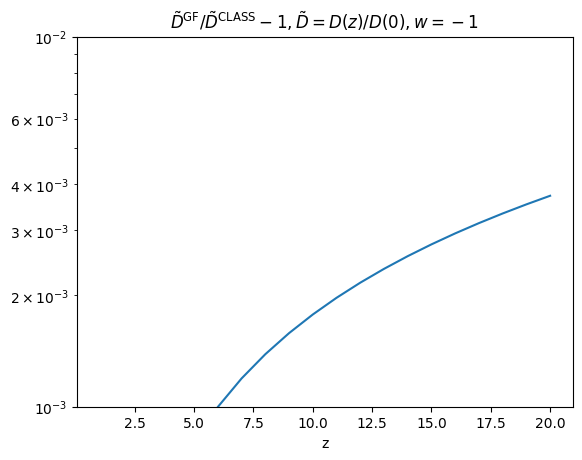

In [10]:
#plt.plot(z,gfD/clD)
plt.plot(z,abs(gfD/clD-1),'-')
plt.semilogy()
plt.xlabel('z')
plt.ylim(1e-3,1e-2)
plt.title(r'$\tilde D^{\rm GF}/\tilde D^{\rm CLASS}-1,\tilde D=D(z)/D(0),w=-1$')

# D ratio

In [11]:

zm = [5,10,20]
ww = np.linspace(-1.5,-0.8,15)
a = len(zm)
b = ww.shape[0]
cD_arr = np.zeros((a,b))
cf_arr = np.zeros((a,b))

sqD_arr = np.zeros((a,b))
sqf_arr = np.zeros((a,b))

cqD_arr = np.zeros((a,b))
cqf_arr = np.zeros((a,b))

for j in range(len(zm)):
    for i in range(len(ww)):
        M,_,_,cD_arr[j,i],cf_arr[j,i] = get_cosmo_at_z(zm[j],ww[i],0)
        
        Omega0_m = M.Omega0_m()
        sqGF = GreenFunction(Omega0_m,w=ww[i],quintessence=False)
        sqf_arr[j,i]=sqGF.fplus(1/(1+zm[j]))
        sqD_arr[j,i]=sqGF.D(1/(1+zm[j]))
    
        cqGF = GreenFunction(Omega0_m,w=ww[i],quintessence=True)
        cqf_arr[j,i]=cqGF.fplus(1/(1+zm[j]))
        cqD_arr[j,i]=cqGF.D(1/(1+zm[j]))

KeyboardInterrupt: 

In [ ]:
sqfratio = []
sqDratio = []
cqfratio = []
cqDratio = []
for i in range(a):
    sqfratio.append(sqf_arr[i]/cf_arr[i])
    sqDratio.append(sqD_arr[i]/cD_arr[i])
    cqfratio.append(cqf_arr[i]/cf_arr[i])
    cqDratio.append(cqD_arr[i]/cD_arr[i])
    
f,ax=plt.subplots(1,2)
color = ['k','r','g','b']
for i in range(a):
    ax[0].plot(ww,(sqfratio[i]/sqfratio[0]),'--',color=color[i],label='f')
    ax[0].plot(ww,(sqDratio[i]/sqDratio[0])**2,color=color[i],label='D**2')
    
    ax[1].plot(ww,cqfratio[i]/cqfratio[0],'--',color=color[i],label='zm={}'.format(zm[i]))
    ax[1].plot(ww,(cqDratio[i]/cqDratio[0])**2,color=color[i])

ax[1].legend()
ax[0].set_xlabel('w')
ax[0].set_title('sq')
ax[1].set_title('cq')
f.suptitle('(ratio at zm)/(ratio at 5),ratio=GF/CLASS')

# additional factor

In [ ]:
def C(a):
    if wa==0 or wa==None:
        return 1+(1+w0)*(1-Omega0_m)/Omega0_m*a**(-3*w0)
    elif wa!=0:
        return 1+(1+w0+wa-a*wa)*(1-Omega0_m)/Omega0_m*a**(-3*w0-3*wa)*np.exp(3*wa*(a-1))
    else:
        raise ValueError('error about dark energy settings')

Omega0_m = 0.3

w0 = -0.95
wa = 0.
factor=[]
zlist=np.linspace(3,10,10)
for zm in zlist:
    am = 1/(1+zm)
    factor.append(quad(C,0,am)[0]/am)

In [ ]:
plt.plot(zlist,np.array(factor)**2,label='w={}'.format(w0))
plt.ylabel('F^2')
plt.xlabel('z')
plt.legend()
plt.axvline(5,linestyle='--')